In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # make the backtester package importable

from backtester import (load_sample, EMACrossover, run_backtest, CostModel,
                        compute_metrics, compare_costs, buy_and_hold,
                        parameter_grid, walk_forward, reconcile_pnl,
                        sharpe_ratio, max_drawdown, infer_periods_per_year)

plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})

prices = load_sample()              # bundled real daily OHLCV; see README for source
PPY = infer_periods_per_year(prices.index)
print(f"{len(prices)} daily bars, {prices.index.min().date()} -> {prices.index.max().date()}")
prices.head()

1259 daily bars, 2013-02-08 -> 2018-02-07


,Open,High,Low,Close,Volume
Date,,,,,
2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416.0
2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425.0
2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363.0
2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995.0
2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154.0


## 1. The data and the signal
The EMA crossover goes long when EMA(5) > EMA(8) and short when EMA(5) < EMA(8). Both EMAs are
causal (they use only past and present closes), so the decision at each bar never peeks ahead.

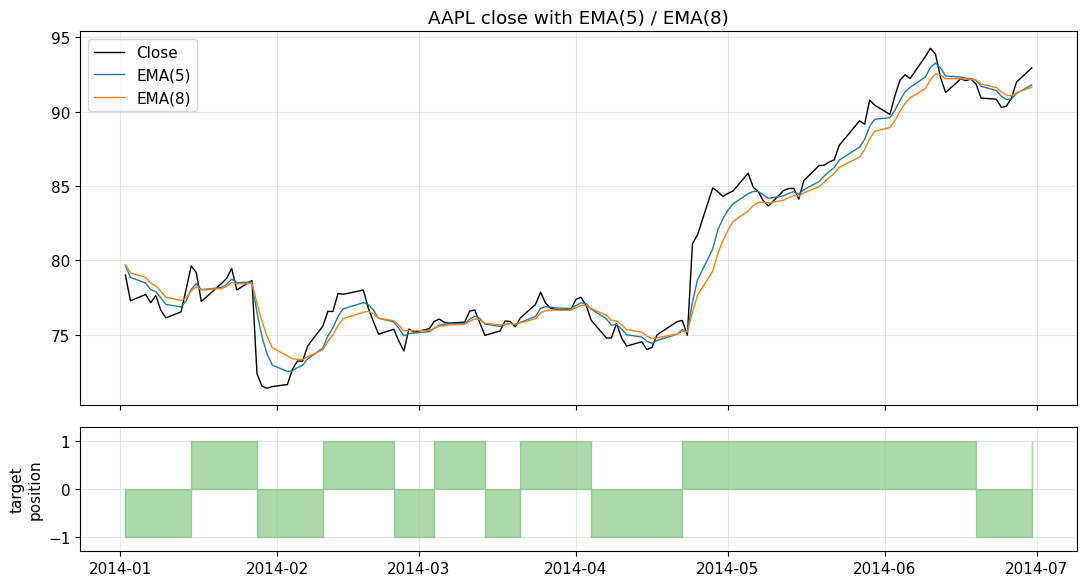

In [2]:
close = prices["Close"]
ema_f = close.ewm(span=5, adjust=False).mean()
ema_s = close.ewm(span=8, adjust=False).mean()
target = EMACrossover(5, 8).generate_signals(prices)

win = slice("2014-01-01", "2014-06-30")   # zoom in so the crossovers are visible
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(close[win], color="black", lw=1, label="Close")
ax1.plot(ema_f[win], color="tab:blue", lw=1, label="EMA(5)")
ax1.plot(ema_s[win], color="tab:orange", lw=1, label="EMA(8)")
ax1.legend(loc="upper left"); ax1.set_title("AAPL close with EMA(5) / EMA(8)")
ax2.fill_between(target[win].index, target[win].values, step="post",
                 color="tab:green", alpha=0.4)
ax2.set_ylabel("target\nposition"); ax2.set_yticks([-1, 0, 1]); ax2.set_ylim(-1.3, 1.3)
plt.tight_layout(); plt.show()

## 2. One backtest, before vs. after costs
The difference between the two runs below is the cost model, so the gap between the equity
curves is the cost of trading, nothing else.

In [ ]:
cost = CostModel()                       # liquid-instrument defaults
gross = run_backtest(prices, target, CostModel.frictionless())
net   = run_backtest(prices, target, cost)
bh    = buy_and_hold(prices, cost)       # benchmark: buy once, hold

resid = reconcile_pnl(net)

cmp = compare_costs(prices, target)
cmp.round(4)

Accounting reconciliation residuals (should be ~0): {'cash_residual': np.float64(0.0), 'trade_residual': 3.601599019020796e-10}
Fills: 119   Closed round-trip trades: 118


,before_costs,after_costs,delta
total_return,0.1195,0.0673,-0.0522
cagr,0.0228,0.0131,-0.0097
sharpe,0.2127,0.1703,-0.0424
ann_vol,0.2250,0.2251,0.0001
max_drawdown,-0.4113,-0.4297,-0.0184
win_rate,0.3136,0.3051,-0.0085
n_trades,118.0000,118.0000,0.0000
ann_turnover_x,46.5150,46.5500,0.0350
final_equity,111947.1954,106729.3577,-5217.8377


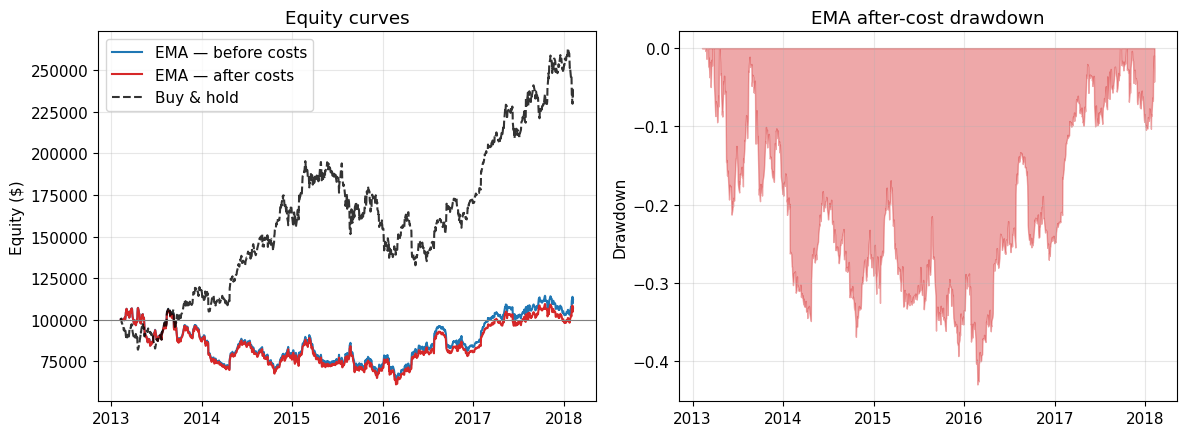

In [4]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))
axL.plot(gross.equity, label="EMA — before costs", color="tab:blue")
axL.plot(net.equity,   label="EMA — after costs",  color="tab:red")
axL.plot(bh,           label="Buy & hold",          color="black", ls="--", alpha=0.8)
axL.axhline(net.initial_cash, color="grey", lw=0.8)
axL.set_title("Equity curves"); axL.set_ylabel("Equity ($)"); axL.legend()

dd = net.equity / net.equity.cummax() - 1.0
axR.fill_between(dd.index, dd.values, color="tab:red", alpha=0.4)
axR.set_title("EMA after-cost drawdown"); axR.set_ylabel("Drawdown")
plt.tight_layout(); plt.show()

## 3. Is the result distinguishable from zero?
A Sharpe number means little without a sense of sampling error. With daily returns over ~5 years we can compute a simple t-statistic for the mean daily return. As a rule of thumb |t| ≳ 2 is the bare minimum to even start taking a mean seriously.

In [5]:
m_net = compute_metrics(net)
r = net.returns[net.returns != 0]
tstat = r.mean() / r.std(ddof=1) * np.sqrt(len(r))

print("EMA(5/8) long/short, AFTER costs")
print(f"  total return : {m_net['total_return']:+.2%}")
print(f"  Sharpe       : {m_net['sharpe']:.2f}")
print(f"  max drawdown : {m_net['max_drawdown']:.2%}")
print(f"  win rate     : {m_net['win_rate']:.1%}  over {m_net['n_trades']} trades")
print(f"  ann. turnover: {m_net['ann_turnover_x']:.1f}x  (very high churn)")
print(f"  daily-return t-stat: {tstat:.2f}   ->  cannot reject 'mean = 0'")
print()
bh_ret = bh.pct_change().fillna(0)
print("Buy & hold benchmark")
print(f"  total return : {bh.iloc[-1]/bh.iloc[0]-1:+.2%}")
print(f"  Sharpe       : {sharpe_ratio(bh_ret, PPY):.2f}")
print(f"  max drawdown : {max_drawdown(bh):.2%}")

EMA(5/8) long/short, AFTER costs
  total return : +6.73%
  Sharpe       : 0.17
  max drawdown : -42.97%
  win rate     : 30.5%  over 118 trades
  ann. turnover: 46.6x  (very high churn)
  daily-return t-stat: 0.38   ->  cannot reject 'mean = 0'

Buy & hold benchmark
  total return : +134.32%
  Sharpe       : 0.85
  max drawdown : -32.08%


## 4. Cost sensitivity
If a strategy's edge is real and large, modest costs barely dent it. If the "edge" is marginal, costs eat it quickly. Here we sweep the total per-side friction (spread + slippage) and watch the after-cost return decay. At very liquid levels the strategy is already weak; at costs typical of a less liquid
instrument it is clearly negative.

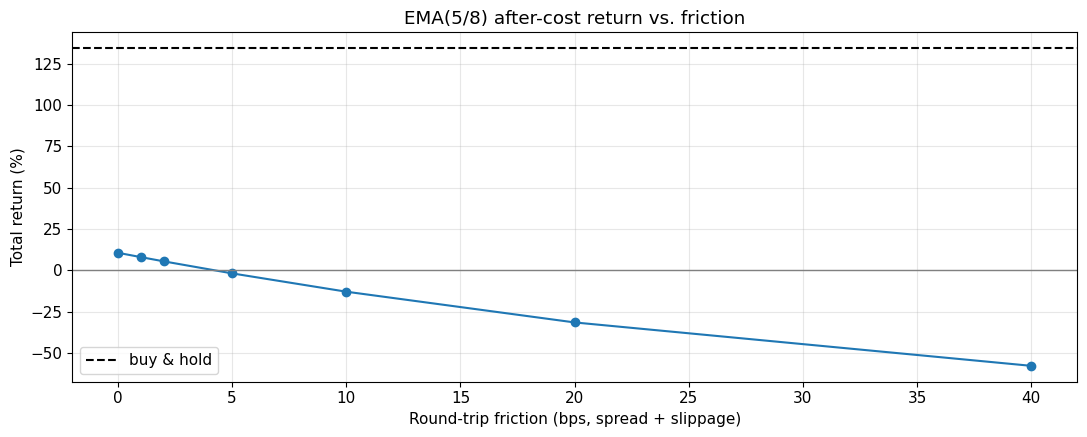

,friction_bps,total_return
0,0,0.1062
1,1,0.0801
2,2,0.0546
3,5,-0.0183
4,10,-0.1290
5,20,-0.3149
6,40,-0.5774


In [6]:
levels_bps = [0, 1, 2, 5, 10, 20, 40]
rets = []
for b in levels_bps:
    cm = CostModel(half_spread_bps=b/2, slippage_bps=b/2, commission_bps=0.5)
    rr = run_backtest(prices, target, cm)
    rets.append(rr.equity.iloc[-1] / rr.initial_cash - 1.0)

plt.figure()
plt.plot(levels_bps, np.array(rets) * 100, marker="o")
plt.axhline(0, color="grey", lw=1)
plt.axhline((bh.iloc[-1]/bh.iloc[0]-1)*100, color="black", ls="--", label="buy & hold")
plt.xlabel("Round-trip friction (bps, spread + slippage)")
plt.ylabel("Total return (%)"); plt.title("EMA(5/8) after-cost return vs. friction")
plt.legend(); plt.tight_layout(); plt.show()
pd.DataFrame({"friction_bps": levels_bps, "total_return": np.round(rets, 4)})

## 5. Parameter sensitivity — the overfitting check
If the strategy captured something real, good performance would form a smooth, connected region in parameter space: nearby (fast, slow) pairs would behave similarly. Instead we see a noisy field where the Sharpe sign flips between neighbouring cells and the best looking pairs are isolated. That is the fingerprint of noise, not edge the "good" cells are where the noise happened to line up.

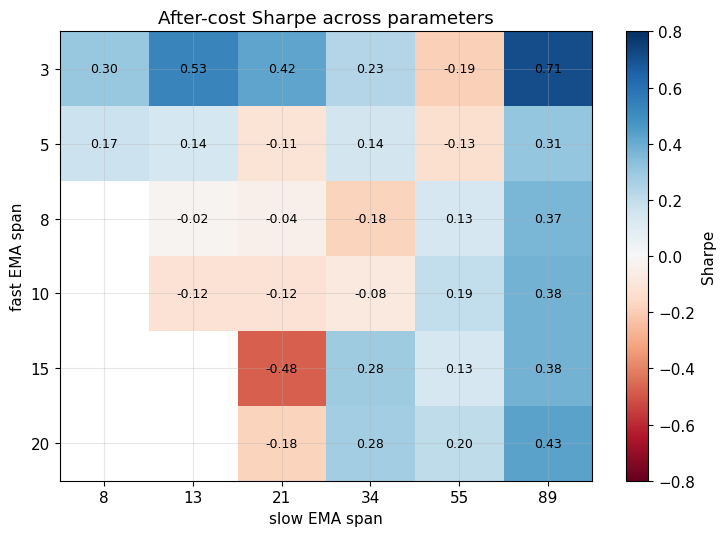

Sharpe over the grid: mean=0.14, min=-0.48, max=0.71, fraction>0=53%


In [7]:
fasts = [3, 5, 8, 10, 15, 20]
slows = [8, 13, 21, 34, 55, 89]
grid = parameter_grid(prices, fasts, slows, metric="sharpe")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
im = ax.imshow(grid.values, cmap="RdBu", vmin=-0.8, vmax=0.8, aspect="auto")
ax.set_xticks(range(len(slows))); ax.set_xticklabels(slows)
ax.set_yticks(range(len(fasts))); ax.set_yticklabels(fasts)
ax.set_xlabel("slow EMA span"); ax.set_ylabel("fast EMA span")
ax.set_title("After-cost Sharpe across parameters")
for i in range(len(fasts)):
    for j in range(len(slows)):
        v = grid.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, label="Sharpe"); plt.tight_layout(); plt.show()
print(f"Sharpe over the grid: mean={np.nanmean(grid.values):.2f}, "
      f"min={np.nanmin(grid.values):.2f}, max={np.nanmax(grid.values):.2f}, "
      f"fraction>0={np.nanmean(grid.values>0):.0%}")

## 6. Walk-forward — and a trap to avoid

Walk forward optimisation picks the best (fast, slow) pair on each training block and then trades it on the next, unseen block. A naive reading of the output below looks almost encouraging: the out-of-sample Sharpe holds up.

But look at which parameters get chosen, the optimiser always lands on the slowest pair offered (a corner solution). A 3/89 crossover is essentially "stay long whenever price is above its ~3-month average," i.e. a long-the-uptrend filter. On a single stock that rose ~130% over the window, that will look good out-of-sample, but it is capturing the asset's drift, not timing skill. The correct control is buy-and-hold over the same out-of-sample window, plotted alongside.

,fold,train_bars,test_bars,chosen_fast,chosen_slow,in_sample_sharpe,oos_sharpe,oos_return
0,2,419,210,3,89,0.851,1.060,0.197
1,3,629,210,3,89,0.962,-0.273,-0.077
2,4,839,210,3,89,0.572,1.130,0.170
3,5,1049,210,3,89,0.658,0.996,0.161


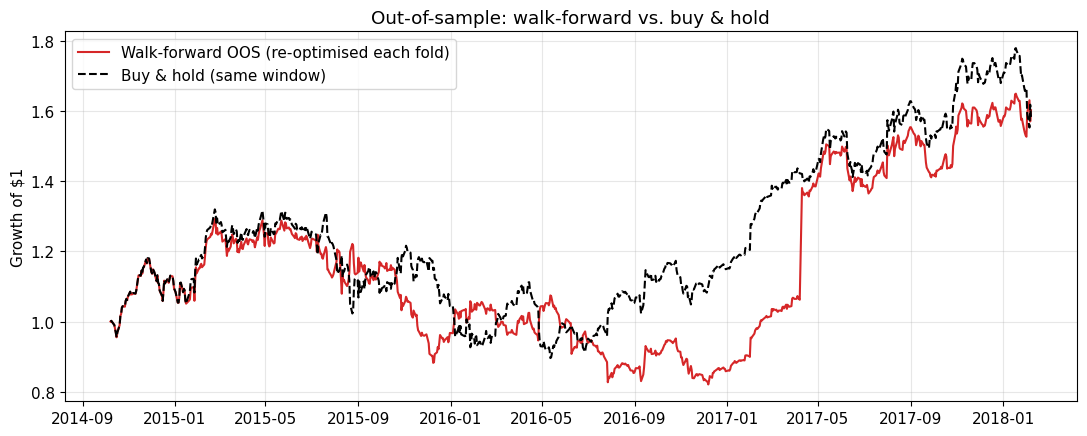

Chosen params each fold: [(3, 89), (3, 89), (3, 89), (3, 89)]
OOS total return  — walk-forward: +60.20%   buy&hold: +58.27%
Mean in-sample Sharpe 0.76 vs mean OOS Sharpe 0.73


In [8]:
summary, oos = walk_forward(prices, fasts, slows, n_splits=5)
display(summary.round(3))

# Benchmark the stitched OOS curve against buy-and-hold over the SAME bars.
bh_oos = bh.loc[oos.index]
oos_n = oos / oos.iloc[0]
bh_n  = bh_oos / bh_oos.iloc[0]

plt.figure()
plt.plot(oos_n, label="Walk-forward OOS (re-optimised each fold)", color="tab:red")
plt.plot(bh_n, label="Buy & hold (same window)", color="black", ls="--")
plt.title("Out-of-sample: walk-forward vs. buy & hold"); plt.ylabel("Growth of $1")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Chosen params each fold: {list(zip(summary.chosen_fast, summary.chosen_slow))}")
print(f"OOS total return  — walk-forward: {oos_n.iloc[-1]-1:+.2%}   buy&hold: {bh_n.iloc[-1]-1:+.2%}")
print(f"Mean in-sample Sharpe {summary.in_sample_sharpe.mean():.2f} vs "
      f"mean OOS Sharpe {summary.oos_sharpe.mean():.2f}")

## 7. Conclusion

- The EMA(5/8) crossover does not beat buying and holding. After realistic costs it returned roughly +7% while buy-and-hold returned +134% over the same five years — and it did so with a larger drawdown and far more risk-taking.
- Its return is statistically indistinguishable from zero. The daily-return t-statistic is ~0.4; he Sharpe (~0.2 before costs, ~0.17 after) is deep in noise territory. Costs make a weak result weaker but are not the whole story — the signal was barely there to begin with.
- It only "works" under cherry-picking. Sharpe sign-flips between neighbouring parameter pairs; there is no smooth region of robust performance. Profitable-looking cells are where noise aligned.
- The one almost-encouraging result is a trap. Walk-forward's out-of-sample Sharpe holds up only because the optimiser drifts to the slowest, near-always-long parameters and the test asset trended up. Benchmarked against buy-and-hold, that apparent skill disappears.
- Caveats kept honest: one asset, one bull-market regime, daily bars, dividends ignored, a simple proportional cost model. None of these caveats rescue the strategy — they only bound the claim.

Bottom line: I trust the finding because the engine is built so the result can't be
an accident of lookahead or sloppy accounting.

### Appendix: running this on fresh data

The bundled sample keeps this notebook reproducible offline. To run your own experiment on live data,
install `yfinance` and swap the loader:

```python
from backtester import load_yfinance
prices = load_yfinance("SPY", start="2010-01-01")   # then re-run from cell 2
```

Everything downstream — engine, metrics, walk-forward — is data-agnostic.